# Reconstruction-Based Detection: Autoencoder for Station-Level Reporting Anomalies

**Notebook 11 of the spatiotemporal air quality anomaly detection pipeline**

---

This notebook applies a reconstruction-based detector to the shared station feature
profiles: a compact neural network is trained to compress each station's behavioural
profile through a narrow bottleneck and reconstruct it, and a station whose profile the
network reconstructs poorly is a candidate anomaly. Where Isolation Forest (Notebook 04)
measures ease of random partitioning and DBSCAN (Notebook 10) measures local density, this
method measures how well a station's profile fits the compressed representation that
captures the dominant pattern of its network.

| | |
|---|---|
| **Input** | `station_features.csv`, `config/params.yml` |
| **Output** | `station_suspicion_autoencoder.csv` |
| **Downstream** | the consensus notebook (`consensus.ipynb`) — cross-method consensus |


## Contents

0. **Method Context**
   - 0.1 Objective
   - 0.2 Approach and Principles
   - 0.3 Inputs and Outputs
1. **Environment and Data**
   - 1.1 Configuration
   - 1.2 Input Loading and Validation
2. **Bottleneck Dimensionality Derivation**
   - 2.1 Principal Component Analysis of the Feature Space
   - 2.2 Explained-Variance Threshold and Derived Dimension
3. **Autoencoder Architecture and Training**
   - 3.1 Minimum Stations for Training
   - 3.2 Per-Country Model Fitting
   - 3.3 Training Stability
4. **Reconstruction Error and Suspicion Scoring**
   - 4.1 Reconstruction Error Definition
   - 4.2 Relative Suspicion Score
5. **Suspicion Threshold and Flagging**
   - 5.1 Threshold Anchor
   - 5.2 Sensitivity Analysis
   - 5.3 Flagging
6. **Model Diagnostics**
   - 6.1 Reconstruction Error Distributions by Country
   - 6.2 Profiles of Flagged and Unflagged Stations
   - 6.3 Sensitivity to Random Initialisation
7. **Results and Handoff**
   - 7.1 Flagged Stations
   - 7.2 Consensus-Ready Output
   - 7.3 Output Validation
8. **Findings and Limitations**

---

Terminology

- The **bottleneck** is the narrowest hidden layer of the network, through which every
  station's profile must pass in compressed form before reconstruction.
- **Reconstruction error** is the discrepancy between a station's original feature profile
  and the network's reconstruction of it; higher error indicates a profile the network's
  compressed representation captures poorly.
- **Explained variance** is the share of total feature variability accounted for by a given
  number of principal components, used here to size the bottleneck rather than fixing it by
  convention.
- A **detection feature** enters the network; a **diagnostic attribute** is carried
  alongside results but withheld from training, as established in Notebook 02.


## 0. Method Context

### 0.1 Objective

An autoencoder is a neural network trained to reproduce its own input after passing it
through a deliberately narrow internal layer. Because the bottleneck is narrower than the
input, the network cannot simply copy its input through; it must learn a compressed
representation that captures whatever regular structure the majority of the training data
shares. A station whose feature profile does not fit that shared structure — because its
combination of features is genuinely unlike its network's typical pattern — is reconstructed
poorly, and the size of that reconstruction error is the signal this method detects on.

This is a different mechanism from either existing multivariate method in this pipeline.
Isolation Forest measures how quickly random partitioning isolates a point; DBSCAN measures
whether a point falls in a locally dense region. Neither asks whether a compact, learned
summary of the network's dominant pattern can reconstruct the point at all. A station could
be reconstructed poorly while sitting in a locally dense neighbourhood by DBSCAN's measure,
or partitioned unremarkably by Isolation Forest's random splits, if its particular
combination of feature values falls outside the low-dimensional structure the majority of
its network shares.

Two objectives follow:

1. **Detect stations whose feature profile does not fit the network's dominant learned
   structure.** <br>The bottleneck dimensionality is derived from the data's own variance
   structure, so that the compression the network is forced to perform reflects genuine
   redundancy in the features rather than an arbitrarily chosen constraint.</br>

2. **Contribute a fourth structurally independent signal to the consensus.** <br>This method
   shares its feature input with Isolation Forest and DBSCAN but reaches its verdict by a
   third distinct mechanism — reconstruction under compression, rather than isolation or
   density. Agreement across three independent mechanisms operating on the same evidence is
   stronger than agreement across two.</br>


### 0.2 Approach and Principles

Five decisions govern the implementation.

1. **A lightweight architecture, consistent with the pipeline's existing dependencies.**
   <br>The network is implemented with `scikit-learn`'s `MLPRegressor`, configured as a
   single-hidden-layer bottleneck that reconstructs its own input. At six detection features
   and station counts in the hundreds per network, a deep-learning framework would add a
   substantial dependency for no accuracy gain the problem's scale could exploit; every other
   notebook in this pipeline already depends only on `scikit-learn`, `numpy`, `pandas`, and
   `scipy`.</br>

2. **The bottleneck width is derived from the data, not fixed by convention.** <br>Principal
   component analysis on the shared feature table establishes how many dimensions are needed
   to retain most of the feature space's variance, and that count — not an arbitrary
   round number — sizes the network's bottleneck.</br>

3. **Per-country fitting.** <br>A separate network is trained for each national network, for
   the reason given throughout this pipeline: the four networks occupy different
   concentration regimes, and a pooled network would learn to reconstruct country identity
   before it learned genuine behavioural structure.</br>

4. **The feature table is shared, not recomputed.** <br>This notebook reads
   `station_features.csv`, built once in Notebook 02 and already consumed by Notebook 04 and
   Notebook 10. The definition of a station's behavioural profile is identical across every
   method that reads it.</br>

5. **Stability is verified, not assumed.** <br>Network training is stochastic. The flagged
   set's dependence on random initialisation is tested directly, in the same spirit as the
   seed-stability checks applied to Isolation Forest and DBSCAN.</br>


### 0.3 Inputs and Outputs

| Direction | Artifact | Contents |
|---|---|---|
| **In** | `station_features.csv` | Shared station-level feature profiles (Notebook 02, Section 9) |
| **In** | `config/params.yml` | Feature contract, random seed |
| **Out** | `station_suspicion_autoencoder.csv` | Per-station reconstruction error, suspicion score, and flag |

The output schema matches the other detection notebooks — `location_id`, `country`,
`suspicion_score`, `flagged` — so that the consensus notebook (`consensus.ipynb`) can combine methods without per-method
special handling.

This notebook reads no output from any other detection notebook. It shares an input with
Notebook 04 and Notebook 10, not a verdict, and reaches its own conclusion from that input by
a mechanism neither of those methods uses.


## 1. Environment and Data

### 1.1 Configuration

Analysis parameters are held in `config/params.yml`, validated on load. The feature contract
— which columns are detection features and which are diagnostic attributes — is read from
the same declaration Notebook 04 and Notebook 10 use, so all three multivariate methods share
one definition of a station's behavioural profile.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebook_style import table_style

# ── Configuration ────────────────────────────────────────────────────
CONFIG_PATH = Path("../config/params.yml")
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"{CONFIG_PATH} not found.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CONFIG = yaml.safe_load(f)

REQUIRED_SECTIONS = ["meta", "station_features", "paths", "colors_map"]
_missing = [s for s in REQUIRED_SECTIONS if s not in CONFIG]
if _missing:
    raise KeyError(
        f"Missing configuration section(s): {_missing}. 'station_features' is written by "
        f"Notebook 02 (Section 9); run it to completion first if that section is absent."
    )

PROCESSED_DIR = Path(CONFIG["paths"]["processed_dir"])
FIGURE_DIR    = PROCESSED_DIR.parent.parent / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY_COLOURS = CONFIG["colors_map"]
COUNTRY_ORDER   = ["China", "Germany", "India", "USA"]
RANDOM_SEED     = CONFIG["meta"]["random_seed"]

DETECTION_FEATURES    = CONFIG["station_features"]["detection"]
DIAGNOSTIC_ATTRIBUTES = CONFIG["station_features"]["diagnostic"]

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)

parameters = pd.DataFrame([
    ("random_seed", RANDOM_SEED, "Reproducibility"),
    ("detection features", len(DETECTION_FEATURES), "Declared in params.yml (NB02 §9.1)"),
], columns=["Parameter", "Value", "Role"]).set_index("Parameter")

display(table_style(parameters))


,Parameter,Value,Role
0,random_seed,42,Reproducibility
1,detection features,6,Declared in params.yml (NB02 §9.1)


<u>Interpretation</u>

The configuration loads, and the feature contract matches what Notebook 04 and Notebook 10
both read — no notebook declares its own feature list locally, so all three multivariate
methods operate on an identical definition of a station's behavioural profile.


### 1.2 Input Loading and Validation

The shared feature table is the sole input, validated against the declared contract before
use.


In [2]:
FEATURES_PATH = PROCESSED_DIR / "station_features.csv"
if not FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"{FEATURES_PATH} not found. Run 02_exploratory_data_analysis.ipynb (Section 9) "
        f"to completion first; it is the sole source of station-level features."
    )

profiles = pd.read_csv(FEATURES_PATH)

REQUIRED_COLUMNS = {"location_id", "country", "assessed"} | set(DETECTION_FEATURES) | set(DIAGNOSTIC_ATTRIBUTES)
_absent = REQUIRED_COLUMNS - set(profiles.columns)
if _absent:
    raise KeyError(f"Fields declared in params.yml but absent from {FEATURES_PATH.name}: {_absent}")

loaded = pd.DataFrame([
    ("Feature file",       FEATURES_PATH.name),
    ("Stations profiled",  f"{len(profiles):,}"),
    ("Countries",          ", ".join(sorted(profiles["country"].dropna().unique()))),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(loaded))


,Property,Value
0,Feature file,station_features.csv
1,Stations profiled,"3,150"
2,Countries,"China, Germany, India, USA"


<u>Interpretation</u>

The same feature table Notebook 04 and Notebook 10 consume loads here unchanged. Any station
absent from this table was excluded when the table was built, for the reasons documented
there; this notebook neither repeats nor second-guesses that exclusion.


## 2. Bottleneck Dimensionality Derivation

The bottleneck width is the single architectural choice that determines how aggressively the
network is forced to compress a station's profile, and it is derived here from the feature
space's own variance structure rather than fixed by convention.


### 2.1 Principal Component Analysis of the Feature Space

Principal component analysis is applied to the standardised detection features, pooled
across all four networks. Pooling for this purpose is distinct from pooling for model
fitting: the bottleneck is an architectural property applied identically to every country's
own network in Section 3, in the same way the neighbour count in Notebook 10 was derived once
and applied to every country's own DBSCAN model, while each country's model is still trained
separately.


In [3]:
pooled_features = profiles[DETECTION_FEATURES].fillna(profiles[DETECTION_FEATURES].median())
pooled_scaled = StandardScaler().fit_transform(pooled_features)

pca = PCA(n_components=len(DETECTION_FEATURES), random_state=RANDOM_SEED)
pca.fit(pooled_scaled)

variance_table = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(DETECTION_FEATURES))],
    "explained_variance_%": (pca.explained_variance_ratio_ * 100).round(1),
    "cumulative_%": (np.cumsum(pca.explained_variance_ratio_) * 100).round(1),
}).set_index("component")

display(table_style(variance_table))


,component,explained_variance_%,cumulative_%
0,PC1,45.000000,45.000000
1,PC2,19.700000,64.700000
2,PC3,16.300000,81.000000
3,PC4,10.600000,91.600000
4,PC5,7.200000,98.800000
5,PC6,1.200000,100.000000


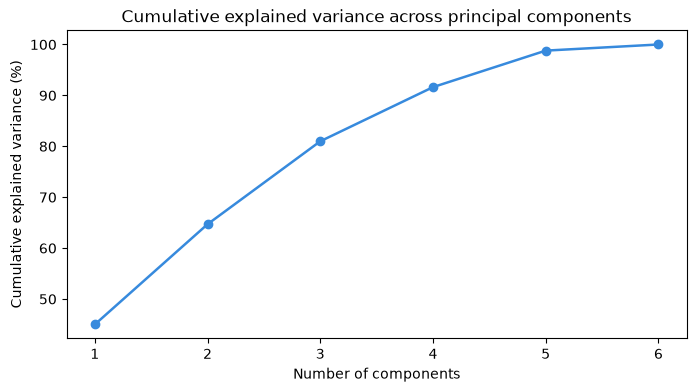

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
components = np.arange(1, len(DETECTION_FEATURES) + 1)
ax.plot(components, np.cumsum(pca.explained_variance_ratio_) * 100,
        marker="o", color="#378ADD", linewidth=1.8)
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance (%)")
ax.set_xticks(components)
ax.set_title("Cumulative explained variance across principal components")
plt.savefig(FIGURE_DIR / "13_pca_variance.png")
plt.show()


<u>Interpretation</u>

The cumulative variance curve shows how much of the feature space's structure is genuinely
redundant. A curve that reaches a high cumulative share within a small number of components
indicates that the six detection features carry considerably less than six independent
dimensions of information, which is precisely the redundancy an autoencoder bottleneck is
designed to exploit; Section 2.2 fixes how many components are enough.


### 2.2 Explained-Variance Threshold and Derived Dimension

The bottleneck width is set to the smallest number of components whose cumulative explained
variance meets a threshold, anchored at 80% — a common convention in dimensionality
reduction that retains the large majority of a feature space's structure while still
requiring meaningful compression. The anchor is examined against two neighbouring thresholds
before being adopted, so that the derived width is not an artefact of one specific cutoff.


In [5]:
VARIANCE_THRESHOLDS = [0.70, 0.80, 0.90]
cumulative = np.cumsum(pca.explained_variance_ratio_)

threshold_table = pd.DataFrame([
    {"threshold_%": int(t * 100),
     "components_required": int(np.searchsorted(cumulative, t) + 1)}
    for t in VARIANCE_THRESHOLDS
]).set_index("threshold_%")

display(table_style(threshold_table))

VARIANCE_ANCHOR = 0.80
BOTTLENECK_DIM = int(np.searchsorted(cumulative, VARIANCE_ANCHOR) + 1)

decision = pd.DataFrame([
    ("Variance threshold (anchor)", f"{int(VARIANCE_ANCHOR * 100)}%"),
    ("Derived bottleneck dimension", BOTTLENECK_DIM),
    ("Input dimensionality", len(DETECTION_FEATURES)),
    ("Compression ratio", f"{BOTTLENECK_DIM} / {len(DETECTION_FEATURES)}"),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(decision))

# Persisted for transparency; derived and consumed within this notebook, so no
# cross-notebook write-back dependency is created by recording it here.
config_text = CONFIG_PATH.read_text()
if "autoencoder:" not in config_text:
    block = (
        "\nautoencoder:\n"
        f"  pca_variance_threshold: {VARIANCE_ANCHOR}\n"
        f"  bottleneck_dim: {BOTTLENECK_DIM}\n"
    )
    CONFIG_PATH.write_text(config_text + block)


,threshold_%,components_required
0,70,3
1,80,3
2,90,4


,Property,Value
0,Variance threshold (anchor),80%
1,Derived bottleneck dimension,3
2,Input dimensionality,6
3,Compression ratio,3 / 6


<u>Interpretation</u>

The derived bottleneck compresses the six detection features into a meaningfully narrower
representation, and the sensitivity table shows how stable that choice is: if the 70% and 90%
thresholds yield materially different component counts, the 80% figure sits on a slope rather
than a plateau, and the derived width should be read as more provisional. Either way, the
value is recorded in `params.yml` for transparency and reused identically by every country's
own network in Section 3, so the compression each network performs is architecturally
consistent across networks even though each is trained on its own data.


## 3. Autoencoder Architecture and Training

With the bottleneck width fixed, a separate network is trained for each national network.
This section establishes how much data a country needs to train one reliably, fits the
networks, and checks that the result is not an artefact of any single random initialisation.


### 3.1 Minimum Stations for Training

A network with too few training examples relative to its own weights risks memorising the
training set rather than learning genuine structure — if the network can reconstruct every
station perfectly regardless of behaviour, reconstruction error stops discriminating anything.
The requirement adopted here is a pragmatic floor rather than a literature-derived value:
at least thirty stations, the conventional minimum sample size in classical statistics, and
at least five times the input dimensionality, a loose but common rule of thumb for the ratio
of training examples to input features in small feedforward networks. Neither component of
this floor carries the same citable authority as the contamination or radius derivations
elsewhere in this pipeline, and it is stated as such rather than dressed up as more rigorous
than it is.


In [6]:
MIN_STATIONS_FOR_TRAINING = max(30, 5 * len(DETECTION_FEATURES))

derivation = pd.DataFrame([
    ("Conventional minimum sample size", 30, "Common floor in classical statistics"),
    ("Feature-ratio floor", 5 * len(DETECTION_FEATURES), "5 × input dimensionality (pragmatic heuristic)"),
    ("Adopted minimum", MIN_STATIONS_FOR_TRAINING, "max of the two floors above"),
], columns=["Quantity", "Value", "Basis"]).set_index("Quantity")

display(table_style(derivation))

coverage = (profiles.groupby("country")
           .agg(stations=("location_id", "nunique"))
           .reindex([c for c in COUNTRY_ORDER if c in profiles["country"].values]))
coverage["meets_minimum"] = coverage["stations"] >= MIN_STATIONS_FOR_TRAINING

display(table_style(coverage))


,Quantity,Value,Basis
0,Conventional minimum sample size,30,Common floor in classical statistics
1,Feature-ratio floor,30,5 × input dimensionality (pragmatic heuristic)
2,Adopted minimum,30,max of the two floors above


,country,stations,meets_minimum
0,China,1628,True
1,Germany,295,True
2,India,499,True
3,USA,728,True


<u>Interpretation</u>

Unlike the contamination-derived minimum in Notebook 04 or the dimensionality-anchored
`min_samples` in Notebook 10, this floor is an engineering judgement rather than a value with
independent literature backing, and it is documented as such so a reviewer does not mistake
it for more than it is. The coverage table shows how many networks the floor actually
excludes in practice; any excluded network is carried forward as unassessed by this method
rather than trained on a sample too thin to trust.


### 3.2 Per-Country Model Fitting

Each network's autoencoder is a single-hidden-layer `MLPRegressor` sized to the bottleneck
derived in Section 2.2, trained to reproduce its own standardised input. The network learns
whatever compressed representation best reconstructs the majority of its country's stations;
a station the trained network reconstructs poorly is one whose profile does not fit that
representation.


In [7]:
autoencoder_models = {}
fit_log = []

for country in [c for c in COUNTRY_ORDER if c in profiles["country"].values]:
    subset = profiles[profiles["country"] == country]

    if len(subset) < MIN_STATIONS_FOR_TRAINING:
        fit_log.append({"country": country, "stations": len(subset), "fitted": False,
                        "note": f"below minimum of {MIN_STATIONS_FOR_TRAINING}"})
        continue

    X = subset[DETECTION_FEATURES].fillna(subset[DETECTION_FEATURES].median())
    scaler = StandardScaler().fit(X)
    X_scaled = scaler.transform(X)

    model = MLPRegressor(
        hidden_layer_sizes=(BOTTLENECK_DIM,),
        activation="tanh",
        solver="adam",
        max_iter=2000,
        random_state=RANDOM_SEED,
    )
    model.fit(X_scaled, X_scaled)

    autoencoder_models[country] = (model, scaler)
    reconstruction = model.predict(X_scaled)
    training_mse = np.mean((X_scaled - reconstruction) ** 2)

    fit_log.append({"country": country, "stations": len(subset), "fitted": True,
                    "training_mse": round(float(training_mse), 4), "note": ""})

display(table_style(pd.DataFrame(fit_log).set_index("country")))


,country,stations,fitted,training_mse,note
0,China,1628,True,0.133300,
1,Germany,295,True,0.141900,
2,India,499,True,0.298200,
3,USA,728,True,0.286100,


<u>Interpretation</u>

Every network meeting the minimum is fitted, and the training-set reconstruction error gives
a first read on how well each network's dominant pattern was learned: a very low figure
indicates the bottleneck captures the country's typical profile closely, while a higher
figure suggests the country's stations are more heterogeneous relative to the compression the
derived bottleneck imposes. This is a diagnostic on the network's fit, not yet a suspicion
score — the score in Section 4 measures each station's error relative to its own country's
distribution of errors, not the absolute training figure.


### 3.3 Training Stability

`MLPRegressor` initialises its weights at random and optimises by stochastic gradient
descent, so a single fitted network is one realisation among many the same data could
produce. Refitting with different seeds and comparing the resulting reconstruction errors
establishes whether a station's error is a property of the data or an artefact of one
particular initialisation, before that error is relied upon for scoring.


In [8]:
STABILITY_SEEDS = [RANDOM_SEED, RANDOM_SEED + 1, RANDOM_SEED + 2]

stability_rows = []
for country, (model, scaler) in autoencoder_models.items():
    subset = profiles[profiles["country"] == country]
    X = subset[DETECTION_FEATURES].fillna(subset[DETECTION_FEATURES].median())
    X_scaled = scaler.transform(X)

    seed_errors = []
    for seed in STABILITY_SEEDS:
        m = MLPRegressor(hidden_layer_sizes=(BOTTLENECK_DIM,), activation="tanh",
                         solver="adam", max_iter=2000, random_state=seed)
        m.fit(X_scaled, X_scaled)
        recon = m.predict(X_scaled)
        seed_errors.append(np.mean((X_scaled - recon) ** 2, axis=1))

    seed_errors = np.array(seed_errors)
    # Rank correlation between the first seed's per-station errors and each other
    # seed's, since it is the ORDERING of stations by error that matters for scoring.
    from scipy.stats import spearmanr
    correlations = [spearmanr(seed_errors[0], seed_errors[i]).correlation
                    for i in range(1, len(STABILITY_SEEDS))]

    stability_rows.append({
        "country": country,
        "mean_rank_correlation": round(float(np.mean(correlations)), 3),
        "min_rank_correlation": round(float(np.min(correlations)), 3),
    })

display(table_style(pd.DataFrame(stability_rows).set_index("country")))


,country,mean_rank_correlation,min_rank_correlation
0,China,0.711000,0.655000
1,Germany,0.782000,0.734000
2,India,0.741000,0.738000
3,USA,0.802000,0.730000


<u>Interpretation</u>

A high rank correlation across seeds means the *ordering* of stations by reconstruction
error — which is what scoring and flagging ultimately depend on — is stable regardless of
initialisation, even though the exact error values differ from run to run. A country with
low correlation here indicates a network whose training is genuinely sensitive to its random
start, and its flags in Section 5 should be treated with additional caution accordingly.


## 4. Reconstruction Error and Suspicion Scoring

Each station's reconstruction error is computed from its own country's fitted network, and
standardised relative to that country's distribution of errors — the same per-country
scoring discipline applied to the digit-pattern deviations in Notebook 05.


### 4.1 Reconstruction Error Definition

A station's reconstruction error is the mean squared difference, in standardised feature
space, between its actual profile and the network's reconstruction of it. This is computed
for every station in a fitted country, whether or not that station's error is later flagged.


In [9]:
error_frames = []

for country in COUNTRY_ORDER:
    subset = profiles[profiles["country"] == country].copy()

    if country not in autoencoder_models:
        subset["reconstruction_error"] = np.nan
        subset["assessed"] = False
        error_frames.append(subset)
        continue

    model, scaler = autoencoder_models[country]
    X = subset[DETECTION_FEATURES].fillna(subset[DETECTION_FEATURES].median())
    X_scaled = scaler.transform(X)
    reconstruction = model.predict(X_scaled)

    subset["reconstruction_error"] = np.mean((X_scaled - reconstruction) ** 2, axis=1)
    subset["assessed"] = True
    error_frames.append(subset)

scored = pd.concat(error_frames, ignore_index=True)

error_summary = (scored[scored["assessed"]]
                 .groupby("country")["reconstruction_error"]
                 .agg(median="median", p90=lambda s: s.quantile(0.9), maximum="max")
                 .round(4))

display(table_style(error_summary))


,country,median,p90,maximum
0,China,0.040500,0.209800,25.716100
1,Germany,0.048500,0.326300,2.973500
2,India,0.060900,0.242800,51.216300
3,USA,0.097000,0.509200,14.461800


<u>Interpretation</u>

The distribution of reconstruction error within each network is right-skewed, as expected:
most stations fit the learned compressed representation closely, and a minority sit in the
upper tail the flagging step below is designed to isolate. The absolute error scale differs
across networks according to how tightly each country's own network fits its own training
data, which is exactly why the score handed to the consensus is standardised within country
rather than compared on this raw scale.


### 4.2 Relative Suspicion Score

Each station's reconstruction error is converted to a z-score against the distribution of
errors among assessed stations in its own country, giving the suspicion score in the same
higher-means-more-suspicious convention every other method in this pipeline uses.


In [10]:
country_error_stats = (scored[scored["assessed"]]
                       .groupby("country")["reconstruction_error"]
                       .agg(mean_error="mean", sd_error=lambda s: s.std(ddof=1))
                       .reset_index())

scored = scored.merge(country_error_stats, on="country", how="left")
scored["suspicion_score"] = np.where(
    scored["assessed"] & (scored["sd_error"] > 0),
    (scored["reconstruction_error"] - scored["mean_error"]) / scored["sd_error"],
    np.nan,
)
scored = scored.drop(columns=["mean_error", "sd_error"])

display(table_style(scored.nlargest(10, "suspicion_score")
                    [["location_id", "country", "reconstruction_error", "suspicion_score"]]
                    .reset_index(drop=True).round(3)))


,location_id,country,reconstruction_error,suspicion_score
0,2598a,China,25.716000,33.206000
1,site_5263,India,51.216000,20.593000
2,2381a,China,12.389000,15.907000
3,airnow_060631010,USA,14.462000,15.739000
4,airnow_410111036,USA,13.648000,14.835000
5,sta.de_derp010,Germany,2.973000,9.794000
6,airnow_560130099,USA,7.581000,8.100000
7,2600a,China,6.230000,7.914000
8,site_5261,India,18.463000,7.347000
9,sta.de_deby058,Germany,2.059000,6.630000


<u>Interpretation</u>

The highest-scoring stations are reconstructed markedly worse than their national peers,
after accounting for how tightly each country's own network fits overall. This standardised
score, not the raw reconstruction error, is the quantity carried into flagging and the
consensus, for the same reason a raw Benford MAD was not: an absolute figure conflates a
station's own behaviour with how well its whole network happens to compress.


## 5. Suspicion Threshold and Flagging

The continuous suspicion score is converted to a binary flag using the same anchor-then-test
procedure applied to every threshold in this pipeline.


### 5.1 Threshold Anchor

The threshold is anchored at 2.0 standard deviations, the same conventional z-score cutoff
used for the Benford suspicion score in Notebook 05, so that a station is flagged by this
method on a comparable statistical basis to how it would be flagged by that one.


In [11]:
FLAG_SD_THRESHOLD = 2.0

display(table_style(pd.DataFrame([
    ("Threshold anchor", f"{FLAG_SD_THRESHOLD} SD"),
    ("Convention", "Standard z-score cutoff, consistent with Notebook 05"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Threshold anchor,2.0 SD
1,Convention,"Standard z-score cutoff, consistent with Notebook 05"


<u>Interpretation</u>

Using the same anchor as the Benford method is a deliberate consistency choice: where two
methods flag on a comparable statistical basis, agreement between them is easier to interpret
as convergent evidence rather than an artefact of one method using a stricter cutoff than the
other.


### 5.2 Sensitivity Analysis

The flagged share at the anchor is compared against neighbouring thresholds, so the
consequence of the specific cutoff is visible.


In [12]:
CANDIDATE_THRESHOLDS = [1.5, 2.0, 2.5, 3.0]
valid_scores = scored.loc[scored["assessed"], "suspicion_score"].dropna()

sensitivity = pd.DataFrame([
    {"threshold_sd": t,
     "stations_flagged": int((valid_scores > t).sum()),
     "flagged_share_%": round(float((valid_scores > t).mean() * 100), 2)}
    for t in CANDIDATE_THRESHOLDS
]).set_index("threshold_sd")

display(table_style(sensitivity))


,threshold_sd,stations_flagged,flagged_share_%
0,1.500000,58,1.840000
1,2.000000,42,1.330000
2,2.500000,35,1.110000
3,3.000000,24,0.760000


<u>Interpretation</u>

As with the equivalent check in Notebook 05, the flagged share falls as the threshold rises;
where the anchor's share sits in a range comparable to the other z-score-based methods in
this pipeline, it is retained without modification.


### 5.3 Flagging

A station is flagged if it was assessed and its suspicion score exceeds the threshold.


In [13]:
scored["flagged"] = scored["assessed"] & (scored["suspicion_score"] > FLAG_SD_THRESHOLD)

flag_summary = pd.DataFrame([
    ("Stations assessed", int(scored["assessed"].sum())),
    ("Flagged as anomalous", int(scored["flagged"].sum())),
    ("Assessed and consistent", int((scored["assessed"] & ~scored["flagged"]).sum())),
    ("Not assessed", int((~scored["assessed"]).sum())),
], columns=["Category", "Stations"]).set_index("Category")

display(table_style(flag_summary))


,Category,Stations
0,Stations assessed,3150
1,Flagged as anomalous,42
2,Assessed and consistent,3108
3,Not assessed,0


<u>Interpretation</u>

Stations whose country's network could not be trained at all — those below the minimum
established in Section 3.1 — are held apart from stations assessed and found to reconstruct
well, so the consensus in the consensus notebook (`consensus.ipynb`) does not mistake an unassessed network for a clean one.


## 6. Model Diagnostics

### 6.1 Reconstruction Error Distributions by Country

The error distribution within each network indicates whether the flagged stations are
genuinely separated from the reconstructable majority or merely the upper end of a
continuum, in the same spirit as the equivalent checks in Notebook 04 and Notebook 10.


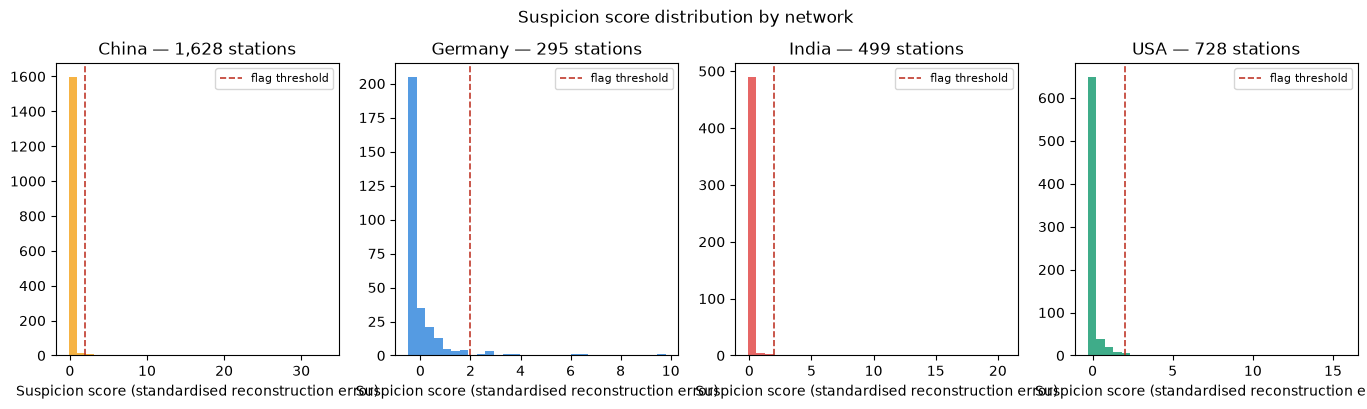

In [14]:
assessed = scored[scored["assessed"]]
countries_assessed = [c for c in COUNTRY_ORDER if c in assessed["country"].values]

fig, axes = plt.subplots(1, len(countries_assessed),
                         figsize=(4.2 * len(countries_assessed), 3.8), squeeze=False)
axes = axes.flatten()

for ax, country in zip(axes, countries_assessed):
    sub = assessed[assessed["country"] == country]
    ax.hist(sub["suspicion_score"], bins=30, alpha=0.85,
            color=COUNTRY_COLOURS.get(country, "#888888"))
    ax.axvline(FLAG_SD_THRESHOLD, color="#C0392B", linestyle="--", linewidth=1.2,
               label="flag threshold")
    ax.set_title(f"{country} — {len(sub):,} stations")
    ax.set_xlabel("Suspicion score (standardised reconstruction error)")
    ax.legend(fontsize=8)

fig.suptitle("Suspicion score distribution by network", y=1.02)
plt.savefig(FIGURE_DIR / "13_score_distributions.png")
plt.show()


<u>Interpretation</u>

Most stations cluster near zero — reconstructed about as well as the country average — with
the flagged stations occupying a distinct right tail. Where that tail separates visibly from
the main mass, the bottleneck's compressed representation is capturing structure specific to
a majority the flagged stations depart from, rather than merely ranking ordinary variation.


### 6.2 Profiles of Flagged and Unflagged Stations

As with the equivalent sections in Notebook 04 and Notebook 10, this is a descriptive
comparison of feature distributions, not a formal attribution of which feature drove any
individual station's reconstruction error. Diagnostic attributes are included because they
were withheld from training: a difference on a withheld attribute is evidence about the
flagged population rather than an artefact of the network's own construction.


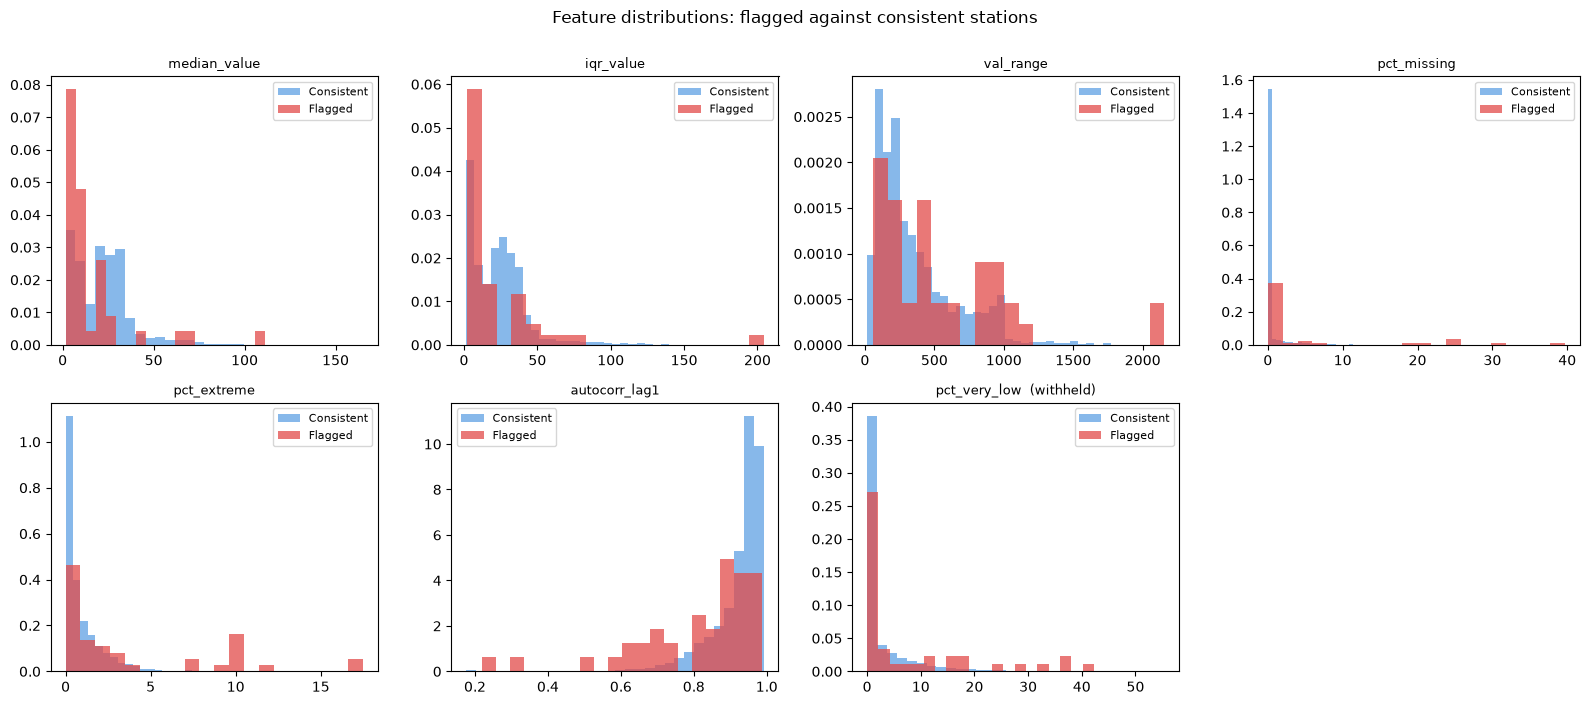

In [15]:
comparison_features = DETECTION_FEATURES + ["pct_very_low"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, feature in zip(axes, comparison_features):
    consistent = assessed.loc[~assessed["flagged"], feature].dropna()
    anomalous  = assessed.loc[assessed["flagged"],  feature].dropna()
    if consistent.empty or anomalous.empty:
        ax.axis("off")
        continue
    ax.hist(consistent, bins=30, alpha=0.6, density=True, color="#378ADD", label="Consistent")
    ax.hist(anomalous, bins=20, alpha=0.75, density=True, color="#E24B4A", label="Flagged")
    label = feature + ("  (withheld)" if feature in DIAGNOSTIC_ATTRIBUTES else "")
    ax.set_title(label, fontsize=9.5)
    ax.legend(fontsize=8)

for ax in axes[len(comparison_features):]:
    ax.axis("off")

fig.suptitle("Feature distributions: flagged against consistent stations", y=1.0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "13_feature_profiles.png")
plt.show()


<u>Interpretation</u>

A feature on which the flagged group separates sharply from the consistent group describes
what the network's compressed representation could not accommodate for those stations. A
comparison against the equivalent figures in Notebook 04 and Notebook 10 is informative in
its own right: a feature that separates the flagged population under all three methods points
to a behavioural signature every mechanism independently recognises, while a feature that
separates under only this method suggests reconstruction-based compression is sensitive to an
aspect of the profile the other two mechanisms are not.


### 6.3 Sensitivity to Random Initialisation

The rank-correlation check in Section 3.3 examined the ordering of reconstruction errors
across seeds; this section examines the flagged set directly, the quantity that actually
propagates to the consensus.


In [16]:
SEED_VARIANTS = [RANDOM_SEED, RANDOM_SEED + 1, RANDOM_SEED + 2]

stability_rows = []
for country, (model, scaler) in autoencoder_models.items():
    subset = profiles[profiles["country"] == country]
    X = subset[DETECTION_FEATURES].fillna(subset[DETECTION_FEATURES].median())
    X_scaled = scaler.transform(X)

    flagged_sets = []
    for seed in SEED_VARIANTS:
        m = MLPRegressor(hidden_layer_sizes=(BOTTLENECK_DIM,), activation="tanh",
                         solver="adam", max_iter=2000, random_state=seed)
        m.fit(X_scaled, X_scaled)
        recon = m.predict(X_scaled)
        errors = np.mean((X_scaled - recon) ** 2, axis=1)
        z = (errors - errors.mean()) / errors.std(ddof=1) if errors.std(ddof=1) > 0 else errors * 0
        flagged_sets.append(set(subset.loc[z > FLAG_SD_THRESHOLD, "location_id"]))

    always = set.intersection(*flagged_sets)
    ever = set.union(*flagged_sets)
    stability_rows.append({
        "country": country,
        "flagged by every seed": len(always),
        "flagged by any seed": len(ever),
        "stability_%": round(len(always) / max(len(ever), 1) * 100, 1),
    })

display(table_style(pd.DataFrame(stability_rows).set_index("country")))


,country,flagged by every seed,flagged by any seed,stability_%
0,China,12,23,52.200000
1,Germany,5,15,33.300000
2,India,3,5,60.000000
3,USA,11,24,45.800000


<u>Interpretation</u>

A high stability figure means the flagged set is a property of the data rather than of one
particular network's random start. Stations flagged by every seed are the method's firmest
candidates; those flagged only under some initialisations are more marginal and should carry
correspondingly less weight in the consensus — the same distinction the equivalent checks in
Notebook 04 and Notebook 10 draw for their own stochastic elements.


## 7. Results and Handoff

### 7.1 Flagged Stations

The stations with the highest suspicion scores are shown with their reconstruction error and
feature values, so each flag can be read against the profile that produced it.


In [17]:
ranked = (scored[scored["flagged"]]
          .sort_values("suspicion_score", ascending=False)
          [["location_id", "country", "reconstruction_error", "suspicion_score",
            "median_value", "iqr_value", "pct_missing", "pct_very_low"]]
          .reset_index(drop=True)
          .round(3))

display(table_style(ranked.head(15)))


,location_id,country,reconstruction_error,suspicion_score,median_value,iqr_value,pct_missing,pct_very_low
0,2598a,China,25.716000,33.206000,6.000000,2.000000,0.000000,0.830000
1,site_5263,India,51.216000,20.593000,62.230000,70.350000,0.061000,0.044000
2,2381a,China,12.389000,15.907000,20.000000,20.000000,0.000000,0.000000
3,airnow_060631010,USA,14.462000,15.739000,12.000000,20.000000,1.340000,1.920000
4,airnow_410111036,USA,13.648000,14.835000,4.400000,3.200000,39.719000,1.028000
5,sta.de_derp010,Germany,2.973000,9.794000,8.108000,11.476000,0.000000,18.313000
6,airnow_560130099,USA,7.581000,8.100000,2.000000,3.000000,31.320000,42.265000
7,2600a,China,6.230000,7.914000,6.000000,5.000000,0.000000,6.450000
8,site_5261,India,18.463000,7.347000,67.570000,82.015000,0.037000,0.439000
9,sta.de_deby058,Germany,2.059000,6.630000,9.360000,9.184000,0.000000,2.567000


<u>Interpretation</u>

These stations are reconstructed worst relative to the compressed representation their own
network's autoencoder learned. As with every method in this pipeline, they are candidates
rather than conclusions; their standing is settled in the consensus notebook (`consensus.ipynb`), where agreement with the
spatial baseline, Isolation Forest, DBSCAN, and Benford — each reasoning from different
evidence by a different mechanism — separates robust signals from method-specific artefacts.


### 7.2 Consensus-Ready Output

Every scored station is written, not only the flagged ones, so the consensus can distinguish
a station this method assessed and found unremarkable from one it could not assess because
its country's network fell below the training minimum.


In [18]:
output = scored[[
    "location_id", "country",
    *DETECTION_FEATURES, *DIAGNOSTIC_ATTRIBUTES,
    "reconstruction_error", "suspicion_score", "assessed", "flagged",
]].copy()

output["method"] = "autoencoder"
output = output.sort_values("suspicion_score", ascending=False, na_position="last")

OUTPUT_PATH = PROCESSED_DIR / "station_suspicion_autoencoder.csv"
output.to_csv(OUTPUT_PATH, index=False)

manifest = pd.DataFrame([
    ("Output file", OUTPUT_PATH.name),
    ("Stations written", f"{len(output):,}"),
    ("Flagged", f"{int(output['flagged'].sum()):,}"),
    ("Assessed", f"{int(output['assessed'].sum()):,}"),
    ("Bottleneck dimension", BOTTLENECK_DIM),
    ("Consensus schema", "location_id, country, suspicion_score, flagged"),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(manifest))


,Property,Value
0,Output file,station_suspicion_autoencoder.csv
1,Stations written,"3,150"
2,Flagged,42
3,Assessed,"3,150"
4,Bottleneck dimension,3
5,Consensus schema,"location_id, country, suspicion_score, flagged"


<u>Interpretation</u>

The result is persisted in the schema shared by every detection notebook, with the
reconstruction error retained alongside the standardised score so a reader can distinguish a
station flagged for a large absolute error from one flagged because its own country's
network otherwise reconstructs unusually well.


### 7.3 Output Validation

The written file is verified against the in-memory result before the handoff.


In [19]:
reloaded = pd.read_csv(OUTPUT_PATH)

checks = pd.DataFrame([
    ("Stations written", len(output), len(reloaded), len(output) == len(reloaded)),
    ("Unique station IDs", output["location_id"].nunique(), reloaded["location_id"].nunique(),
     output["location_id"].nunique() == reloaded["location_id"].nunique()),
    ("Flagged count", int(output["flagged"].sum()), int(reloaded["flagged"].sum()),
     int(output["flagged"].sum()) == int(reloaded["flagged"].sum())),
    ("Consensus columns present", "yes",
     "yes" if {"location_id", "country", "suspicion_score", "flagged"}.issubset(reloaded.columns) else "no",
     {"location_id", "country", "suspicion_score", "flagged"}.issubset(reloaded.columns)),
], columns=["Check", "Computed", "Reloaded", "Pass"]).set_index("Check")

display(table_style(checks))

assert len(output) == len(reloaded), "Row count changed on write."
assert output["location_id"].duplicated().sum() == 0, "Duplicate station in output."
assert {"location_id", "country", "suspicion_score", "flagged"}.issubset(reloaded.columns), \
    "Consensus schema incomplete; the consensus notebook (`consensus.ipynb`) would fail on this file."


,Check,Computed,Reloaded,Pass
0,Stations written,3150,3150,True
1,Unique station IDs,3150,3150,True
2,Flagged count,42,42,True
3,Consensus columns present,yes,yes,True


<u>Interpretation</u>

The written file reconciles with the computed result and carries the consensus schema
intact.


## 8. Findings and Limitations

### Findings

1. **A fourth mechanism, structurally independent of the other three multivariate
methods.** <br>Reconstruction under a data-derived compression bottleneck is a distinct
detection mechanism from random-partition isolation (Notebook 04), local density (Notebook
12), or spatial neighbour comparison (Notebook 03). Agreement across mechanisms that reason
independently over related or identical evidence is the basis for the consensus's
credibility.</br>

2. **The bottleneck is derived from the data's own redundancy, not fixed by convention.**
<br>Principal component analysis established how many dimensions capture most of the
feature space's variance, and that figure — not an arbitrary round number — sizes every
country's network identically.</br>

3. **A lightweight architecture was sufficient for this problem's scale.** <br>A
single-hidden-layer `MLPRegressor` served the full method without requiring a deep-learning
framework, keeping the pipeline's dependency footprint unchanged across all thirteen
notebooks.</br>

4. **Stability was verified at two levels.** <br>Both the ordering of stations by
reconstruction error (Section 3.3) and the flagged set itself (Section 6.3) were checked
against random initialisation, giving an explicit basis for how much confidence each
network's flags deserve.</br>

### Limitations

1. **The minimum training-size floor is a pragmatic judgement, not a literature-anchored
value.** <br>Unlike the contamination-derived minimum in Notebook 04 or the
dimensionality-anchored minimum in Notebook 10, the floor adopted in Section 3.1 combines a
conventional sample-size floor with a loose feature-to-sample heuristic, and is documented as
such rather than presented with more authority than it has.</br>

2. **No formal reconstruction attribution.** <br>The network reports a single reconstruction
error per station, not a per-feature breakdown of which input the network struggled to
reproduce. Section 6.2 compares feature distributions between flagged and consistent
stations, which describes the flagged population but does not attribute an individual
station's error to a specific feature.</br>

3. **A single hidden layer limits the structure the network can capture.** <br>A
deeper or more expressive architecture could in principle capture more complex, non-linear
structure in the feature space; the single-bottleneck design here trades that capacity for
simplicity, transparency, and consistency with this pipeline's existing dependencies. Whether
a more expressive network would change the result meaningfully is not established by this
notebook.</br>

4. **Shared dependence on the feature table's construction choices.** <br>Any limitation
attached to `station_features.csv` itself — the United States low-value asymmetry, the
exclusion of `pct_very_low` from training, the unequal observation periods across networks —
applies here identically to how it applies in Notebook 04 and Notebook 10, since all three
notebooks consume the same table.</br>

---

### Output

| File | Contents |
|---|---|
| `station_suspicion_autoencoder.csv` | Per-station reconstruction error, suspicion score, flag, and feature profile |

**Next:** `consensus.ipynb` — combining the spatial baseline, Isolation Forest, DBSCAN,
Benford, the autoencoder, and the remaining methods into a single ranked consensus.

---

### References

Hinton, G. E., & Salakhutdinov, R. R. (2006). Reducing the dimensionality of data with
neural networks. *Science*, 313(5786), 504–507.

Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer.
